In [26]:
import os
import pandas as pd
import numpy as np

path = os.path.join( "..", "data", "processed", "maillage_geo_enriched.csv")
df = pd.read_csv(path)

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_92343/638059358.py:6: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [28]:
df.head()

,cell_id,grav,vma,obs,obsm,agg,int,atm,catr,circ,...,dep,com,TMJA,lit,bridge,tunnel,traffic_calming,dist_hop_m,dist_fire_m,nb_accidents
0,414909_89708,2.0,80,0.0,2.0,1,1.0,1.0,2.0,2.0,...,2A,2A163,39672.0,no,no,no,no,991.972403,2896.945736,3
1,414945_89572,3.0,80,0.0,6.0,1,1.0,1.0,2.0,2.0,...,2A,2A163,39672.0,no,no,yes,no,1320.281832,438.778055,1
2,414963_89627,2.0,80,0.0,2.0,1,1.0,1.0,2.0,2.0,...,2A,2A163,39672.0,no,no,no,no,2427.671931,1915.973045,2
3,414981_89488,2.0,80,0.0,2.0,1,1.0,1.0,2.0,2.0,...,2A,2A272,39672.0,yes,no,no,no,4361.358876,2330.589050,2
4,414981_89501,1.5,80,0.0,2.0,1,1.0,1.0,2.0,2.0,...,2A,2A163,39672.0,yes,no,no,no,455.291323,3303.309305,2


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232080 entries, 0 to 232079
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   cell_id          232080 non-null  object 
 1   grav             232080 non-null  float64
 2   vma              232080 non-null  int64  
 3   obs              232080 non-null  float64
 4   obsm             232080 non-null  float64
 5   agg              232080 non-null  int64  
 6   int              232080 non-null  float64
 7   atm              232080 non-null  float64
 8   catr             232080 non-null  float64
 9   circ             232080 non-null  float64
 10  prof             232080 non-null  float64
 11  plan             232080 non-null  float64
 12  surf             232080 non-null  float64
 13  infra            232080 non-null  float64
 14  situ             232080 non-null  float64
 15  dep              232080 non-null  object 
 16  com              232080 non-null  obje

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_2832/3835316146.py:25: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = (pd.read_csv("../data/processed/maillage_geo_enriched.csv",


✅  Graph final : Data(x=[232080, 186], edge_index=[2, 58968], y=[232080], train_mask=[232080], val_mask=[232080], test_mask=[232080], pos=[232080, 2])
E010  tr_loss 0.205  tr_acc 0.894  val_acc 0.894
E020  tr_loss 0.251  tr_acc 0.878  val_acc 0.878
E030  tr_loss 0.184  tr_acc 0.875  val_acc 0.875
E040  tr_loss 0.132  tr_acc 0.877  val_acc 0.876
E050  tr_loss 0.099  tr_acc 0.902  val_acc 0.901
E060  tr_loss 0.089  tr_acc 0.910  val_acc 0.910
E070  tr_loss 0.086  tr_acc 0.912  val_acc 0.911
E080  tr_loss 0.086  tr_acc 0.912  val_acc 0.912
E090  tr_loss 0.085  tr_acc 0.913  val_acc 0.913
E100  tr_loss 0.084  tr_acc 0.913  val_acc 0.913

🎯  Test accuracy : 0.912
🔎 Seuil F1‑max : 0.41  (F1=0.647)
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     30319
           1       0.60      0.67      0.63      4493

    accuracy                           0.90     34812
   macro avg       0.78      0.80      0.79     34812
weighted avg       0.91    

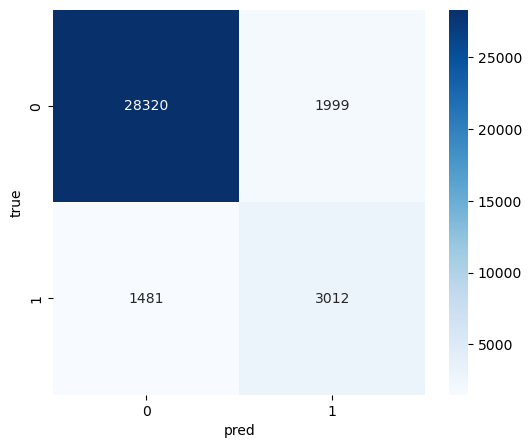

In [2]:
############
# Pred grav avec nb_accident catégories regroupées (1+2 vs 3+4)
# GAT 3 couches
#############

# ════════════════════════════════════════════════════════════
# 0)  LIBRAIRIES & CHARGEMENT
# ════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, torch, torch.nn.functional as F
from torch import nn
from torch_geometric.data import Data
from torch_geometric.transforms import RandomNodeSplit
from torch_geometric.nn import GATConv, BatchNorm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from collections import defaultdict
import geopandas as gpd                    # pour la distance au pôle urbain
from shapely.geometry import Point
import joblib

# ------------------------------------------------------------------
# 0 a)  DataFrame
# ------------------------------------------------------------------
df = (pd.read_csv("../data/processed/maillage_geo_enriched.csv",
                  low_memory=False, dtype=str)
        .apply(pd.to_numeric, errors="ignore"))

df = df.drop(columns=["com",
                      "surf"])


df["grav"] = df["grav"].astype(int)
df["grav"] = df["grav"].replace(2,1)
df["grav"] = df["grav"].replace(3,2)
df["grav"] = df["grav"].replace(4,2)


# ------------------------------------------------------------------
# 0 b)  Coords + cible
# ------------------------------------------------------------------
DEC = 4                                    # même valeur que lors du maillage
df[["lat10","lon10"]] = df["cell_id"].str.split("_",expand=True).astype(int)
df["lat_deg"] = df["lat10"] / 10**DEC
df["lon_deg"] = df["lon10"] / 10**DEC

y_all = df["grav"].values - 1         # 0 based  (N,)

# ════════════════════════════════════════════════════════════
# 1)  SPLIT  (pré leakage safe)
# ════════════════════════════════════════════════════════════
train_idx, temp_idx = train_test_split(np.arange(len(df)),
                                       test_size=0.30,
                                       stratify=y_all,
                                       random_state=42)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.5,
                                       stratify=y_all[temp_idx],
                                       random_state=42)

train_idx = train_idx.tolist()
val_idx   = val_idx.tolist()
test_idx  = test_idx.tolist()

mask_train = torch.zeros(len(df), dtype=torch.bool)
mask_val   = torch.zeros(len(df), dtype=torch.bool)
mask_test  = torch.zeros(len(df), dtype=torch.bool)

mask_train[train_idx] = True
mask_val  [val_idx]   = True
mask_test [test_idx]  = True

# ════════════════════════════════════════════════════════════
# 2)  FEATURES  (→ X_num, X_cat, features spatiales)
# ════════════════════════════════════════════════════════════
# ------------------------------------------------------------------
# 2 a) coordonnées centrées / réduites (aucune fuite)
# ------------------------------------------------------------------
sc_coord = StandardScaler().fit(df.loc[train_idx,["lat_deg","lon_deg"]])
df[["lat_norm","lon_norm"]] = sc_coord.transform(df[["lat_deg","lon_deg"]])

# ------------------------------------------------------------------
# 2 c) liste finale des colonnes
# ------------------------------------------------------------------
num_cols = ["vma","TMJA","lat_norm","lon_norm","nb_accidents","dist_hop_m","dist_fire_m"]
cat_cols = ['lit','dep','agg','catr','obs','obsm','situ','prof','plan','infra','circ','int',"bridge","tunnel","traffic_calming"]

scaler = StandardScaler().fit(df.loc[train_idx, num_cols])
ohe    = OneHotEncoder(handle_unknown="ignore", sparse_output=False
                      ).fit(df.loc[train_idx, cat_cols].astype(str))

X_num = scaler.transform(df[num_cols])
X_cat = ohe.transform(df[cat_cols].astype(str))
X_tab = np.hstack([X_num, X_cat]).astype(np.float32, copy=False)

# ════════════════════════════════════════════════════════════
# 3)  VOISINAGE 8 connexe ➜ edge_index
# ════════════════════════════════════════════════════════════
coords = df[["lat10","lon10"]].values
index_by_cell = defaultdict(list)
for idx,(la,lo) in enumerate(coords):
    index_by_cell[(la,lo)].append(idx)

edges=[]
for (la,lo),nodes in index_by_cell.items():
    for dlat,dlon in [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]:
        neigh=(la+dlat,lo+dlon)
        if neigh in index_by_cell:
            for i in nodes:
                for j in index_by_cell[neigh]:
                    edges.append([i,j])
edge_index = torch.tensor(edges,dtype=torch.long).t().contiguous()

# ════════════════════════════════════════════════════════════
# 4)  Target Encoding « com »
# ════════════════════════════════════════════════════════════
#te = TargetEncoder(smoothing=10, min_samples_leaf=100)
#te.fit(df.loc[train_idx,"com"], df.loc[train_idx,"grav"])
#com_te = te.transform(df["com"]).values.astype("float32").reshape(-1,1)

# concat features   (sans .numpy())
x_tensor = torch.cat([
        torch.tensor(X_tab.tolist(), dtype=torch.float32)#,
#        torch.tensor(com_te.tolist(), dtype=torch.float32)
], dim=1)
y_tensor = torch.tensor(y_all.tolist(), dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor,
            train_mask=mask_train, val_mask=mask_val, test_mask=mask_test)

data.pos = torch.tensor(
    df[["lat_deg", "lon_deg"]].values,  # (N, 2)
    dtype=torch.float32
)

print("✅  Graph final :", data)

# ════════════════════════════════════════════════════════════
# 5)  Focal Loss
# ════════════════════════════════════════════════════════════
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5):       # γ = 1.5 ici
        super().__init__(); self.gamma=gamma
    def forward(self, logits, targets):
        logp = F.log_softmax(logits, dim=1)
        p    = torch.exp(logp)
        return F.nll_loss((1-p)**self.gamma * logp, targets)

# ════════════════════════════════════════════════════════════
# 6)  GAT (32 têtes, + features spatiales)
# ════════════════════════════════════════════════════════════
class GATResNet(nn.Module):
    def __init__(self, in_dim, hidden=32, out_dim=2, heads=8, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.gats = nn.ModuleList([
            GATConv(in_dim, hidden, heads=heads, dropout=dropout),
            GATConv(hidden * heads, hidden, heads=heads, dropout=dropout),
            GATConv(hidden * heads, hidden, heads=heads, dropout=dropout),
        ])
        self.bns = nn.ModuleList([
            BatchNorm(hidden * heads),
            BatchNorm(hidden * heads),
            BatchNorm(hidden * heads),
        ])
        self.res0 = nn.Linear(in_dim, hidden * heads, bias=False)
        self.final = GATConv(hidden * heads, out_dim, heads=1, concat=False)

    def forward(self, data):
        x, ei = data.x, data.edge_index
        h = self.gats[0](x, ei)
        h = F.elu(self.bns[0](h))
        x = self.res0(x) + h
        x = F.dropout(x, p=self.dropout, training=self.training)
        for gat, bn in zip(self.gats[1:], self.bns[1:]):
            h = F.elu(bn(gat(x, ei)))
            x = x + h
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.final(x, ei)

device = torch.device("cpu")  # ou 'cuda' / 'mps'

model = GATResNet(
    in_dim   = data.x.size(1),
    hidden   = 32,     # même largeur qu’avant
    out_dim  = int(data.y.max()) + 1,
    heads    = 8,      # ↓ têtes
    dropout  = 0.1
).to(device)

data = data.to(device)

criterion = FocalLoss(gamma=1.5)
#criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.,3]))
opt  = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)  #1e-4
sched= torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)

def step(mask, update=False):
    model.train(update)
    opt.zero_grad()
    out  = model(data)[mask]
    loss = criterion(out, data.y[mask])
    if update:
        loss.backward(); opt.step()
    acc  = (out.argmax(1)==data.y[mask]).float().mean().item()
    return loss.item(), acc

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


for epoch in range(1, 101):
    loss_tr, _ = step(data.train_mask, update=True)

    # Enregistre les résultats toutes les 10 epochs
    if epoch % 10 == 0:
        loss_tr_eval, acc_tr = step(data.train_mask)
        loss_va, acc_va = step(data.val_mask)
        sched.step(loss_va)

        # Log les valeurs
        train_losses.append(loss_tr_eval)
        val_losses.append(loss_va)
        train_accuracies.append(acc_tr)
        val_accuracies.append(acc_va)

        print(f"E{epoch:03d}  tr_loss {loss_tr_eval:.3f}  tr_acc {acc_tr:.3f}  val_acc {acc_va:.3f}")

_,acc_test = step(data.test_mask)
print(f"\n🎯  Test accuracy : {acc_test:.3f}")


import joblib

history = {
    "loss_tr": train_losses,
    "loss_va": val_losses,
    "acc_tr": train_accuracies,
    "acc_va": val_accuracies
}

joblib.dump(history, "../models/history_gat.joblib")

# ════════════════════════════════════════════════════════════
# 6 bis)  choisit le seuil optimal sur le jeu de validation
# ════════════════════════════════════════════════════════════
model.eval()
with torch.no_grad():
    logits_val = model(data)[data.val_mask]
    probas_val = logits_val.softmax(1)[:, 1].cpu().tolist()   # p(classe 1)
    y_val      = data.y[data.val_mask].cpu().tolist()

from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(y_val, probas_val)

# Si on veut maximiser la F1 :

f1   = 2 * prec * rec / (prec + rec + 1e-9)
best = f1.argmax()
best_thr = thr[best] if best < len(thr) else 0.5
print(f"🔎 Seuil F1‑max : {best_thr:.2f}  (F1={f1[best]:.3f})")

# Si on veut maximiser la precision :

#prec   = prec[1:]
#rec    = rec[1:]
#thr    = thr            # même taille que prec/rec maintenant

# (option) garder un rappel minimum, ex. > 0.10
#mask   = rec > 0.30
#best_i = np.argmax(prec[mask])
#best_thr = thr[mask][best_i]

#print(f"Seuil max‑precision (recall>10 %) : {best_thr:.3f} "
#      f"precision={prec[mask][best_i]:.2f}  recall={rec[mask][best_i]:.2f}")

# ════════════════════════════════════════════════════════════
# 7)  MATRICE DE CONFUSION
# ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    logits_test = model(data)[data.test_mask]
    probas_test = logits_test.softmax(1)[:, 1].cpu().tolist()
    preds       = (probas_test > best_thr).astype(int)      # ← seuil validé
    true        = data.y[data.test_mask].cpu().tolist()

print(classification_report(true, preds))
cm = confusion_matrix(true, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("pred"); plt.ylabel("true"); plt.show()

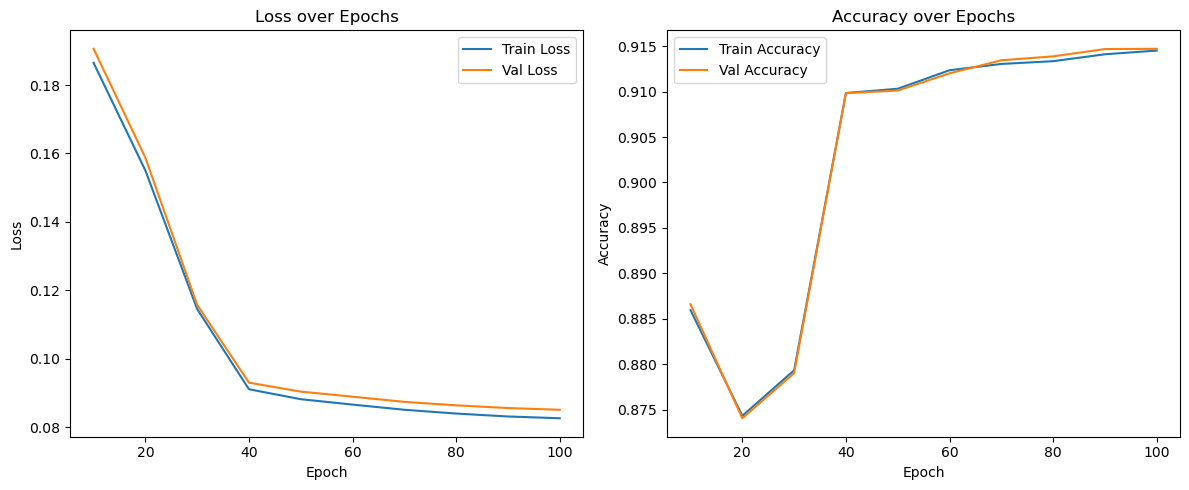

In [8]:
import matplotlib.pyplot as plt

epochs = list(range(10, 101, 10))  
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012707 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3074
[LightGBM] [Info] Number of data points in the train set: 185664, number of used features: 191
[LightGBM] [Info] Start training from score 0.213204
R² proxy : 0.9856944766796839


/opt/anaconda3/envs/env_torch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


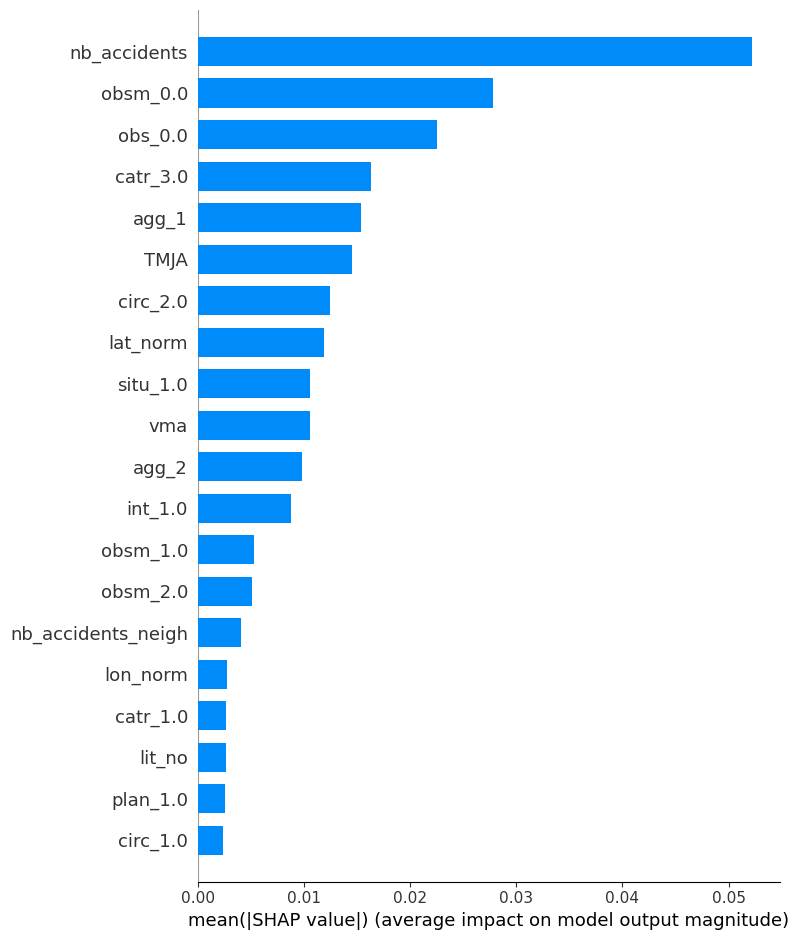

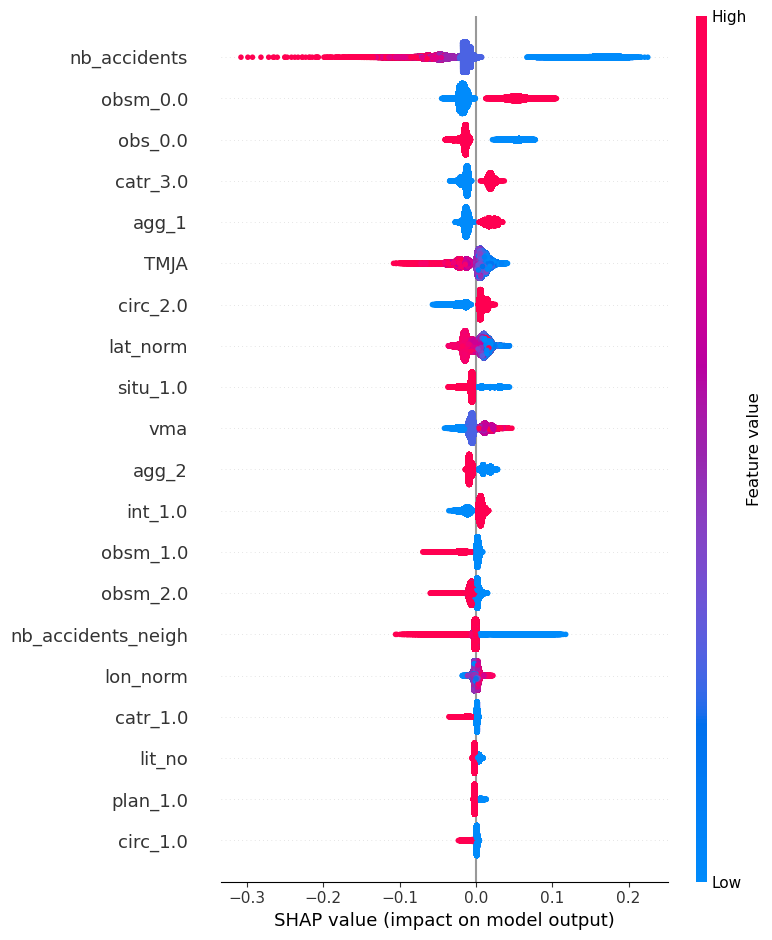

In [4]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler

# ---- features du nœud -------------------------------------------------
df_flat = pd.DataFrame(data.x.cpu().tolist(), columns=[
        *num_cols,                               # vma, TMJA, …
        *ohe.get_feature_names_out(cat_cols),    # lit_no, situ_1.0, …
        
])



# ---- voisinage (moyenne des features continues) ----------------------
# edge_index : [2, E]
src, dst = data.edge_index.cpu().tolist()
nbrs = [[] for _ in range(len(df_flat))]
for s, d in zip(src, dst):
    nbrs[d].append(s)          # in-neighbors

for col in num_cols:
    neigh_mean = [
        df_flat.loc[idxs, col].mean() if idxs else np.nan
        for idxs in nbrs
    ]
    df_flat[f"{col}_neigh"] = neigh_mean

# valeurs NA → moyenne globale
df_flat = df_flat.fillna(df_flat.mean())

with torch.no_grad():
    proba_gnn = model(data).softmax(1)[:, 1].cpu().numpy()  # (N,)
y_reg = proba_gnn   # régression sur [0,1]

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_flat, y_reg, test_size=0.2, random_state=42)

lgb = LGBMRegressor(
    n_estimators=600,
    max_depth=-1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
).fit(X_train, y_train)

print("R² proxy :", lgb.score(X_test, y_test))

import shap
explainer = shap.TreeExplainer(lgb)
shap_values = explainer.shap_values(df_flat, check_additivity=False)  # (N, F)

shap.summary_plot(shap_values, df_flat, plot_type="bar")

shap.summary_plot(shap_values, df_flat)   # beeswarm


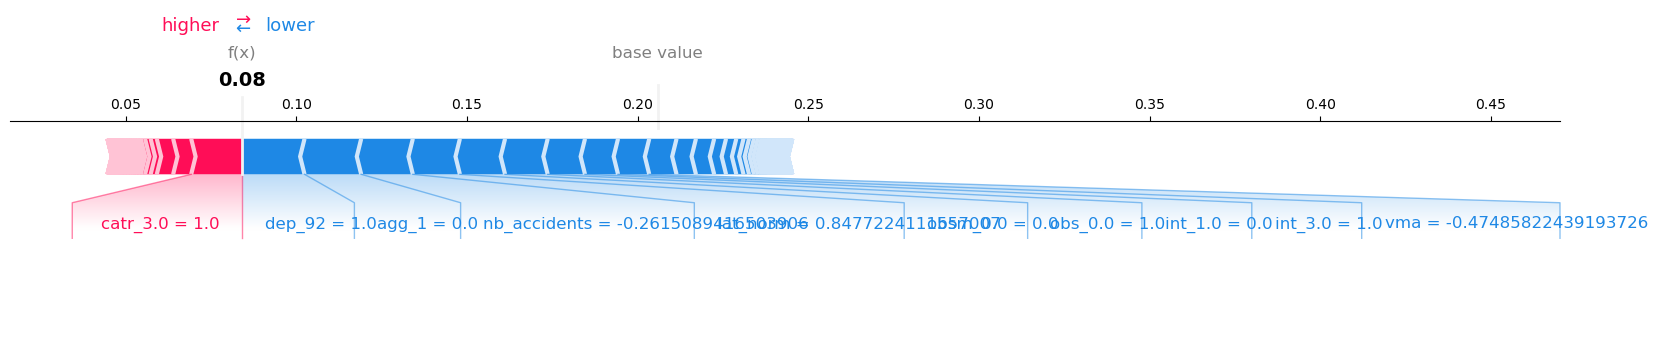

In [11]:
# Visualisation d'un tronçon random

import random
chosen_idx = random.randint(0, data.num_nodes - 1)

shap.force_plot(
    explainer.expected_value,
    shap_values[chosen_idx],
    df_flat.iloc[chosen_idx],
    matplotlib=True
)

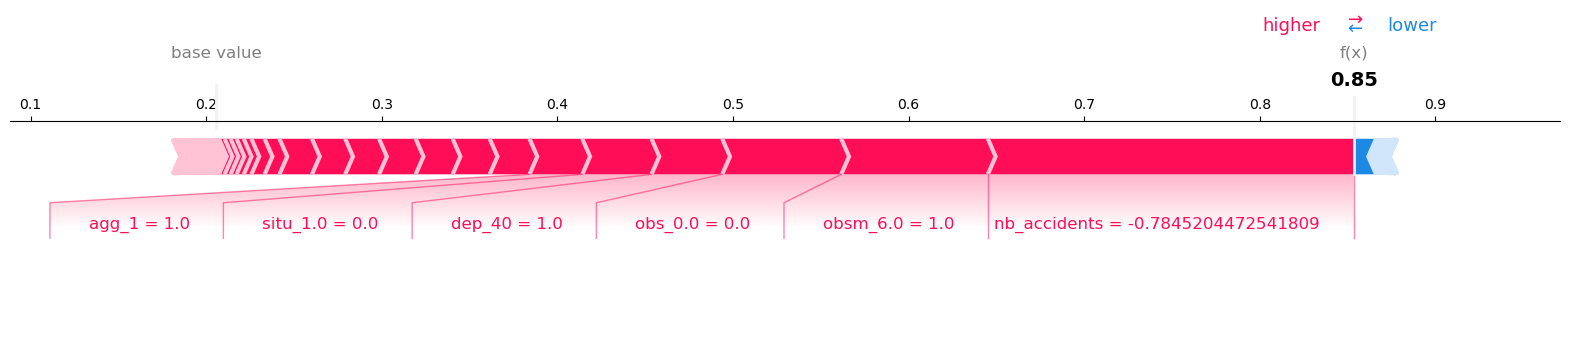

In [8]:
# Visualisation du tronçon avec la plus grande gravité

with torch.no_grad():
    proba = model(data).softmax(dim=1)[:, 1].cpu().numpy()

chosen_idx = proba.argmax()  # le tronçon le plus grave selon le modèle

shap.force_plot(
    explainer.expected_value,
    shap_values[chosen_idx],
    df_flat.iloc[chosen_idx],
    matplotlib=True
)

In [5]:
import joblib

joblib.dump(model, "../models/GAT.joblib")
joblib.dump(shap_values, "../models/shap_values.joblib")
joblib.dump(explainer, "../models/explainer.joblib")

torch.save(data.cpu(), "../models/data.pt")
df_flat.to_csv("../data/processed/df_flat.csv", index=False)
df.to_csv("../data/processed/GAT_df.csv", index=False)
joblib.dump(ohe, "../models/ohe.joblib")
joblib.dump(best_thr, "../models/best_thr.joblib")


['../models/best_thr.joblib']

In [2]:
torch.save(model.state_dict(), "../models/GAT_weights.pt")


/opt/anaconda3/envs/env_torch/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


📦 Téléchargement/génération des images…


100%|██████████| 232080/232080 [6:04:43<00:00, 10.61it/s]    


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/sebastienlebreton/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 55.3MB/s]
CNN → feats: 100%|██████████| 1814/1814 [1:18:51<00:00,  2.61s/it]
/opt/anaconda3/envs/env_torch/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Embeddings UMAP shape: torch.Size([232080, 128])
🚀 Training …
E10 val F1=0.550 thr=0.71
E20 val F1=0.576 thr=0.58
E30 val F1=0.599 thr=0.74
E40 val F1=0.606 thr=0.74
E50 val F1=0.608 thr=0.76
E60 val F1=0.610 thr=0.76
E70 val F1=0.612 thr=0.79
E80 val F1=0.613 thr=0.79
E90 val F1=0.616 thr=0.75
E100 val F1=0.616 thr=0.78

Test report (seuil optimal: 0.7757641 )
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     30319
           1       0.58      0.64      0.61      4493

    accuracy                           0.89     34812
   macro avg       0.76      0.79      0.77     34812
weighted avg       0.90      0.89      0.90     34812



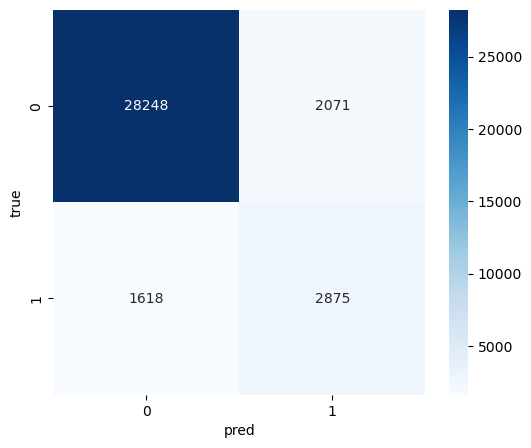

In [ ]:
#!/usr/bin/env python
"""
Satellite + Embeddings + GAT — pipeline complet (UMAP 128 + seuil F1-max)
=======================================================================
• ZOOM              = 18  (≈0.6m/px)
• IMG SIZE          = 64
• BATCH             = 128 (DataLoader)
• DEVICE            = CUDA si dispo
• UMAP dims         = 128 (min_dist=0.1, n_neighbors=30)
• LOSS              = CrossEntropy + poids auto (classe 1 pondérée)
• THRESHOLD         = Calculé F1-max sur **validation**

Étapes :
1. Vérifie la présence de `data` (PyG) avec `data.pos` (lat, lon).
2. Télécharge / génère les vignettes OSM en cache JPEG (5 décimales).
3. Embeddings ResNet50 (TorchGeo NAIP) ⇒ **UMAP 128d** ⇒ cache `img_embeds.npy`.
4. Fusion features tabulaires + embeddings (pondération learnable a, β).
5. Entraîne GAT (3 couches, heads=8).
6. Cherche seuil F1-max sur validation → applique au test.
"""
!pip install umap-learn

from __future__ import annotations
import math, gc, numpy as np, torch, contextily as cx
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import umap
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_curve, classification_report
from torch_geometric.nn import GATConv, BatchNorm
import torch.nn.functional as F
import torch.nn as nn
import torch.multiprocessing as mp

from torchvision.models import resnet50, ResNet50_Weights



try:
    if mp.get_start_method(allow_none=True) != "fork":
        mp.set_start_method("fork", force=True)
except RuntimeError:
    pass

IMG_DIR = Path("sat_images"); IMG_DIR.mkdir(exist_ok=True)
ZOOM, SIZE_PX, BATCH = 18, 64, 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EARTH_CIRCUM = 40075016.686

# ───────────────────────────── contextily helpers ──────────

def contextily_tile(lat: float, lon: float, zoom=ZOOM, size_px=SIZE_PX):
    meters_px = EARTH_CIRCUM / 2**(zoom + 8)
    half_lat = (meters_px * size_px / 2) / 111_320
    half_lon = half_lat / math.cos(math.radians(lat))
    west, east = lon - half_lon, lon + half_lon
    south, north = lat - half_lat, lat + half_lat
    arr, _ = cx.bounds2img(west, south, east, north, zoom=zoom, ll=True,
                           source=cx.providers.OpenStreetMap.Mapnik)
    img = Image.fromarray(arr)
    if img.mode == "RGBA":
        img = img.convert("RGB")
    return img.resize((size_px, size_px))

def cache_path(lat, lon):
    return IMG_DIR / f"{lat:.5f}_{lon:.5f}.jpg"

def safe_get_or_create(lat, lon):
    p = cache_path(lat, lon)
    if not p.exists():
        try:
            contextily_tile(lat, lon).save(p, "JPEG", quality=90)
        except Exception:
            Image.new("RGB", (SIZE_PX, SIZE_PX)).save(p)
    return p

class SatDS(Dataset):
    def __init__(self, lat_arr, lon_arr, tf):
        self.lat = lat_arr; self.lon = lon_arr; self.tf = tf
    def __len__(self): return len(self.lat)
    def __getitem__(self, idx):
        img = Image.open(safe_get_or_create(float(self.lat[idx]), float(self.lon[idx]))).convert("RGB")
        return self.tf(img)

# ───────────────────────────── Pré‑requis PyG `data` ───────
# ─────────── Si `data` absent, charge à partir d'un fichier `data.pt` ─────
DATA_PATH = Path("../models/data.pt")
if "data" not in globals():
    if DATA_PATH.exists():
        data = torch.load(DATA_PATH)
        print("✅ data chargé depuis '../models/data.pt'")
    else:
        raise FileNotFoundError("Aucun objet `data` trouvé en mémoire, ni fichier 'data.pt' dans le répertoire.")

try:
    data  # noqa
except NameError:
    raise RuntimeError("Charge d'abord votre objet PyG `data` contenant data.pos.")
if getattr(data, "pos", None) is None:
    raise RuntimeError("data.pos absent dans l'objet PyG.")

lat_deg = data.pos[:,0].cpu().numpy(); lon_deg = data.pos[:,1].cpu().numpy()

print("📦 Téléchargement/génération des images…")
for lat, lon in tqdm(list(zip(lat_deg, lon_deg))):
    safe_get_or_create(lat, lon)

# ───────────────────────────── Embeddings TorchGeo ResNet50 + UMAP ──
emb_path = IMG_DIR/"img_embeds.npy"
if emb_path.exists():
    img_embeds = torch.tensor(np.load(emb_path))
else:
    tf = transforms.Compose([
        transforms.Resize((SIZE_PX, SIZE_PX)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    dl = DataLoader(SatDS(lat_deg, lon_deg, tf), batch_size=BATCH, shuffle=False)
    resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    backbone = torch.nn.Sequential(*list(resnet.children())[:-1]).to(DEVICE).eval()
    feats = []
    with torch.no_grad():
        for batch in tqdm(dl, desc="CNN → feats"):
            feats.append(backbone(batch.to(DEVICE)).squeeze().cpu())
    feats = torch.cat(feats).numpy()
    reducer = umap.UMAP(n_components=128, min_dist=0.1, n_neighbors=30, metric="cosine", random_state=42)
    img_embeds = torch.tensor(reducer.fit_transform(feats), dtype=torch.float32)
    np.save(emb_path, img_embeds.numpy())
    del feats, backbone, resnet; gc.collect()

print("Embeddings UMAP shape:", img_embeds.shape)

# ───────────────────────────── Fusion learnable α, β ───────
class FusionLayer(nn.Module):
    def __init__(self):
        super().__init__(); self.alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x_tab, x_img):
        a = torch.sigmoid(self.alpha)
        return torch.cat([a * x_tab, (1-a) * x_img], dim=1)

fusion = FusionLayer()
with torch.no_grad():
    x_tab = (data.x - data.x.mean(dim=0)) / (data.x.std(dim=0)+1e-6)
    x_img = (img_embeds - img_embeds.mean(dim=0)) / (img_embeds.std(dim=0)+1e-6)
    data.x = fusion(x_tab, x_img)

# ───────────────────────────── GAT ──────────────────────────
class GATResNet(nn.Module):
    def __init__(self, in_dim, hidden=32, out_dim=2, heads=8, drop=0.1):
        super().__init__(); self.drop=drop
        self.convs = nn.ModuleList([
            GATConv(in_dim, hidden, heads=heads, dropout=drop),
            GATConv(hidden*heads, hidden, heads=heads, dropout=drop),
            GATConv(hidden*heads, hidden, heads=heads, dropout=drop)
        ])
        self.bns = nn.ModuleList([BatchNorm(hidden*heads) for _ in range(3)])
        self.res0 = nn.Linear(in_dim, hidden*heads, bias=False)
        self.final = GATConv(hidden*heads, out_dim, heads=1, concat=False)
    def forward(self, d):
        x, ei = d.x, d.edge_index
        h = F.elu(self.bns[0](self.convs[0](x, ei)))
        x = self.res0(x)+h; x = F.dropout(x, p=self.drop, training=self.training)
        for conv,bn in zip(self.convs[1:], self.bns[1:]):
            h = F.elu(bn(conv(x, ei))); x = x+h
        return self.final(x, ei)

model = GATResNet(data.x.shape[1]).to(DEVICE)

y_np = data.y.cpu().numpy()
weights = torch.tensor(compute_class_weight('balanced', classes=np.unique(y_np), y=y_np), dtype=torch.float32, device=DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=weights)
opt = torch.optim.AdamW(list(model.parameters())+list(fusion.parameters()), lr=2e-3)

print("🚀 Training …")
for epoch in range(1, 101):
    model.train(); fusion.train(); opt.zero_grad()
    out = model(data)[data.train_mask]
    loss = loss_fn(out, data.y[data.train_mask])
    loss.backward(); opt.step()
    if epoch%10==0:
        model.eval(); fusion.eval()
        with torch.no_grad():
            logits_val = model(data)[data.val_mask]
            probs_val = F.softmax(logits_val,1)[:,1].cpu(); y_val = data.y[data.val_mask].cpu()
            prec, rec, thr = precision_recall_curve(y_val, probs_val)
            f1 = 2*prec*rec/(prec+rec+1e-9); best = f1.argmax(); best_thr = thr[best] if best < len(thr) else 0.5
            print(f"E{epoch:02d} val F1={f1[best]:.3f} thr={best_thr:.2f}")

model.eval(); fusion.eval()
logits_test = model(data)[data.test_mask]
probs_test = torch.softmax(logits_test,1)[:,1].cpu(); y_test = data.y[data.test_mask].cpu()
y_pred = (probs_test > best_thr).long()

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns
print("\nTest report (seuil optimal:", best_thr,")")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("pred"); plt.ylabel("true"); plt.show()
